Algoritmos Genéticos - Variações
-eaMuPlusLambda
-eaMuCommaLambda
-eaSimple


In [1]:
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 4.1 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import array
import random
import numpy

from deap import algorithms
from deap import base
from deap import creator
from deap import tools


In [23]:
# Gera o toolbox responsável por registrar as configurações dp framework
toolbox = base.Toolbox()

# Cria o tipo de função fitness e indivíduo
creator.create("Maximization", base.Fitness, weights=(1.0,))
creator.create("Genes", list, fitness=creator.Maximization)

# Registra os nomes e osa tipos de indivíduo, fitness e população
toolbox.register("Atributo", random.randint, 0, 1)
toolbox.register("Cromossomo", tools.initRepeat, creator.Genes, toolbox.Atributo, 300) # 50 bits de 0 e 1
toolbox.register("Populacao", tools.initRepeat, list, toolbox.Cromossomo) # é uma lista de listas que são cromossomos


In [24]:
def fitnessFunction(chromosome):
  return sum(chromosome),

In [59]:
# Parâmetros dos Algoritmos
prob_cx=0.8
prob_mt=0.1
nger=300
tamPop=20

# Estratégia Evolutiva (Mu_Lambda)
mu = 20
_lambda = 20

In [60]:
# Registra os operadores. Deve-se manter os nomes evaluate, mate, mutate e select.
toolbox.register("evaluate", fitnessFunction)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.01)
toolbox.register("select", tools.selBest)

In [61]:
# Gera o formato de análise estatística
st = tools.Statistics(lambda ind: ind.fitness.values)
st.register("max", numpy.max)
st.register("avg", numpy.mean)

In [62]:
# Estratégia Evolutiva: Mu_Plus_Lambda
pop = toolbox.Populacao(n=mu)

In [63]:
# Executa o algoritmo eaMuPlusLambda
finalPop, log = algorithms.eaMuPlusLambda(pop, toolbox, mu, _lambda, prob_cx, prob_mt, nger, stats = st, verbose=False)

In [64]:
# Imprime a melhor solução da população final
melhorSolucao = tools.selBest(finalPop, 1)
print(f'Melhor Fitness: {melhorSolucao[0].fitness.values}')

Melhor Fitness: (260.0,)


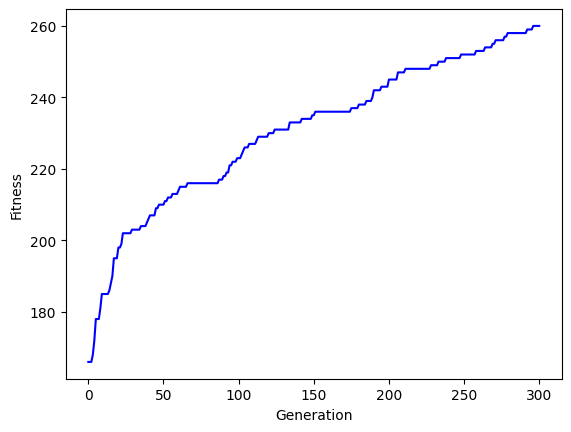

In [65]:
# Plotagem das melhores soluções
import matplotlib.pyplot as plt

maxFit = log.select("max")

plt.plot(maxFit, color='blue')
plt.xlabel('Generation')
plt.ylabel('Fitness')
plt.show()

In [66]:
# Estratégia Evolutiva: Mu_Comma_Lambda

In [67]:
# Define a quantidade de filhos
_lambda = 30

In [68]:
# Define o tamanho da População
pop = toolbox.Populacao(n=mu)


In [74]:
# Executa o algoritmo eaMuPlusLambda
finalPop, log = algorithms.eaMuCommaLambda(pop, toolbox, mu, _lambda, prob_cx, prob_mt, nger, stats = st, verbose=False)

In [75]:
# Imprime a melhor solução da população final
melhorSolucao = tools.selBest(finalPop, 1)
print(f'Melhor Fitness: {melhorSolucao[0].fitness.values}')

Melhor Fitness: (294.0,)


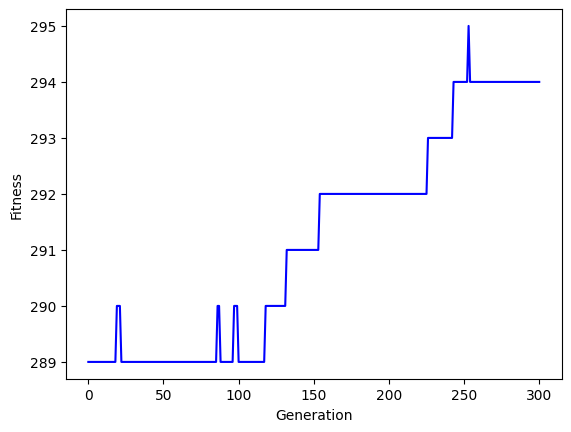

In [76]:
# Plotagem das melhores soluções
import matplotlib.pyplot as plt

maxFit = log.select("max")

plt.plot(maxFit, color='blue')
plt.xlabel('Generation')
plt.ylabel('Fitness')
plt.show()

In [ ]:
# Algoritmo genético

In [77]:
# Define o tamanho da população
pop = toolbox.Populacao(n=tamPop)

In [78]:
# Executa o algoritmo eaSimples
finalPop, log = algorithms.eaSimple(pop, toolbox, prob_cx, prob_mt, nger, stats = st, verbose=False)

In [79]:
# Imprime a melhor solução da opulação final
melhorSolucao = tools.selBest(finalPop, 1)
print(f'Melhor Fitness: {melhorSolucao[0].fitness.values}')

Melhor Fitness: (217.0,)


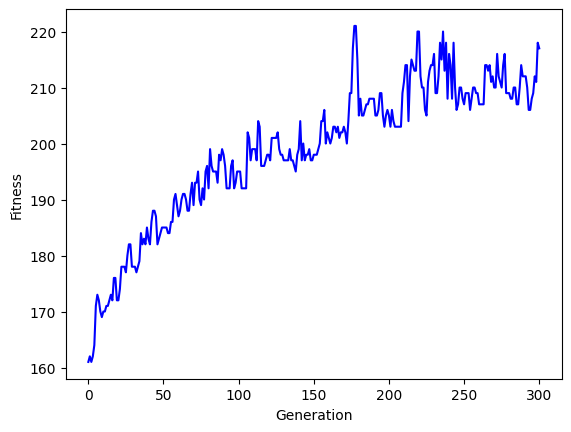

In [80]:
# Plotagem das melhores soluções
import matplotlib.pyplot as plt

maxFit = log.select("max")

plt.plot(maxFit, color='blue')
plt.xlabel('Generation')
plt.ylabel('Fitness')
plt.show()